# Commercial Dimension — EDA

Exploratory analysis of the commercial feature matrix (`feature_matrix_commercial.csv`,
542 PLR × 60 features). Structure parallel to the real-estate dimension:

1. **Distributions** — histograms of the level features (pure inspection: skew / NaN / median
   shown as information, *no* transformation applied)
2. **Correlation** — Spearman heatmap of the levels, to find redundant variables

This notebook covers the **levels only** (the 2026 state) plus the two raw counts
`com_n_gastro`, `com_n_upscale`. Each variable is shown twice side by side: all 542 PLR vs.
only PLR with a gastronomic base (`com_has_gastro_structure == 1`).

In [57]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

In [58]:
# --- load the final feature matrix ---
csv = Path("../../data/final_datasets")
df = pd.read_csv(csv / "feature_matrix_commercial.csv", dtype={"plr_id": str})
print("shape:", df.shape)
print("PLR with gastro structure:", int(df["com_has_gastro_structure"].sum()), "of", len(df))

# gastro-applicable subset (analogous to RE's miet_dimension_anwendbar == 1)
cs = df[df["com_has_gastro_structure"] == 1].copy()
print("subset shape:", cs.shape)

shape: (542, 61)
PLR with gastro structure: 470 of 542
subset shape: (470, 61)


## Step 1 — Distributions of the level features

Pure inspection, nothing is transformed. Left column: **all 542 PLR**. Right column:
**only PLR with gastronomic structure**. Title shows skew, NaN count and median as
orientation — not as a transformation rule.

Note on reading skew: it is most meaningful for the raw counts and the quotients
(right-skewed, long tails). For the bounded shares [0,1] and for median_age it is
informational only.

In [59]:
# 19 level variables (2026 state) + the two raw counts
level_vars = [
    # demographics
    "com_median_age_level_2026",
    "com_share_max_1y_level_2026", "com_share_max_2y_level_2026", "com_share_max_5y_level_2026",
    "com_share_min_20y_level_2026", "com_share_min_30y_level_2026", "com_share_min_40y_level_2026",
    "com_share_solo_level_2026", "com_share_1_9_level_2026", "com_share_10plus_level_2026",
    # gastronomy
    "com_gastro_share_level_2026", "com_upscale_share_level_2026",
    "com_gastro_quotient_bezirk_level_2026", "com_gastro_quotient_berlin_level_2026",
    "com_upscale_quotient_bezirk_level_2026", "com_upscale_quotient_berlin_level_2026",
    # tourism
    "com_tourism_share_level_2026", "com_tourism_quotient_bezirk_level_2026",
    "com_tourism_quotient_berlin_level_2026",
    # raw counts
    "com_n_gastro", "com_n_upscale",
]
print(len(level_vars), "variables")

21 variables


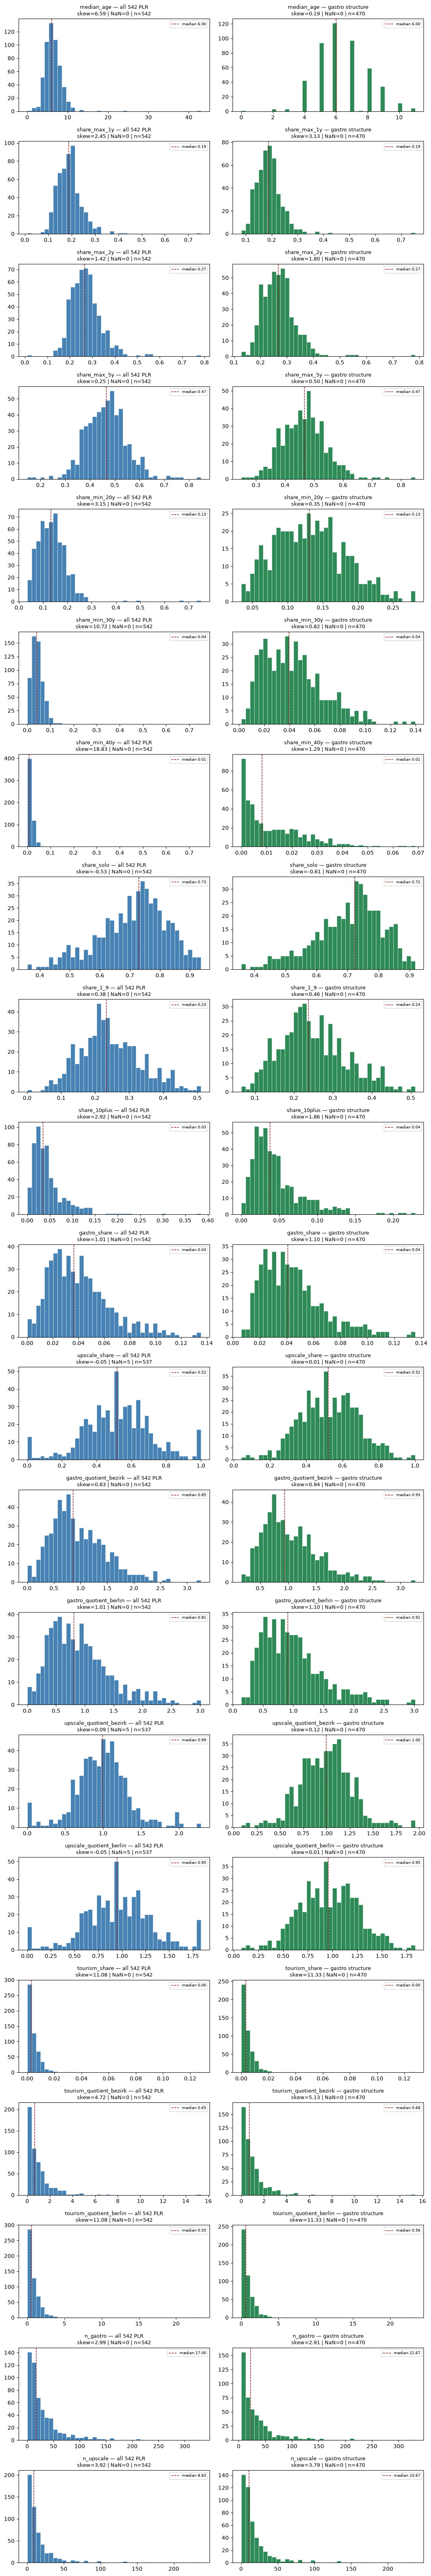

In [60]:
# side-by-side histograms: all 542 PLR (left) vs gastro-structure subset (right)
def hist_pair(col, ax_all, ax_sub):
    for ax, data, label, color in [
        (ax_all, df[col], "all 542 PLR", "steelblue"),
        (ax_sub, cs[col], "gastro structure", "seagreen"),
    ]:
        d = data.dropna()
        ax.hist(d, bins=40, color=color, edgecolor="white", linewidth=0.4)
        if len(d):
            ax.axvline(d.median(), color="darkred", linestyle="--", linewidth=1,
                       label=f"median {d.median():.2f}")
            ax.legend(fontsize=7)
        skew = d.skew() if len(d) > 2 else float("nan")
        n_na = int(data.isna().sum())
        short = col.replace("com_", "").replace("_level_2026", "")
        ax.set_title(f"{short} — {label}\nskew={skew:.2f} | NaN={n_na} | n={len(d)}", fontsize=9)

n = len(level_vars)
fig, axes = plt.subplots(n, 2, figsize=(11, 3.1 * n))
for i, col in enumerate(level_vars):
    hist_pair(col, axes[i, 0], axes[i, 1])
plt.tight_layout()
plt.show()

### Skew overview (compact)

Quick tabular overview — which variables are asymmetric? Description only, no consequence yet.

In [61]:
rows = []
for col in level_vars:
    d_all = df[col].dropna()
    d_sub = cs[col].dropna()
    rows.append({
        "variable": col.replace("com_", ""),
        "skew_all": round(d_all.skew(), 2) if len(d_all) > 2 else np.nan,
        "skew_sub": round(d_sub.skew(), 2) if len(d_sub) > 2 else np.nan,
        "median_all": round(d_all.median(), 3) if len(d_all) else np.nan,
        "NaN_all": int(df[col].isna().sum()),
    })
skew_tab = pd.DataFrame(rows).sort_values("skew_all", key=lambda s: s.abs(), ascending=False)
print(skew_tab.to_string(index=False))

                          variable  skew_all  skew_sub  median_all  NaN_all
          share_min_40y_level_2026     18.83      1.29       0.008        0
tourism_quotient_berlin_level_2026     11.08     11.33       0.552        0
          tourism_share_level_2026     11.08     11.33       0.003        0
          share_min_30y_level_2026     10.72      0.82       0.040        0
             median_age_level_2026      6.59      0.19       6.000        0
tourism_quotient_bezirk_level_2026      4.72      5.13       0.652        0
                         n_upscale      3.92      3.79       8.833        0
          share_min_20y_level_2026      3.15      0.35       0.132        0
                          n_gastro      2.99      2.91      17.000        0
           share_10plus_level_2026      2.92      1.86       0.035        0
           share_max_1y_level_2026      2.45      3.13       0.187        0
           share_max_2y_level_2026      1.42      1.80       0.266        0
 gastro_quot

## Step 2 — Correlation matrix (Spearman)

Computed on the gastro-applicable subset across the level features. Spearman (rank-based)
is robust to the skew/outliers still present in the raw features. The goal is to surface
**redundant variables** — e.g. a quotient that is near-perfectly correlated with its
underlying share — so we can decide which to drop before clustering.

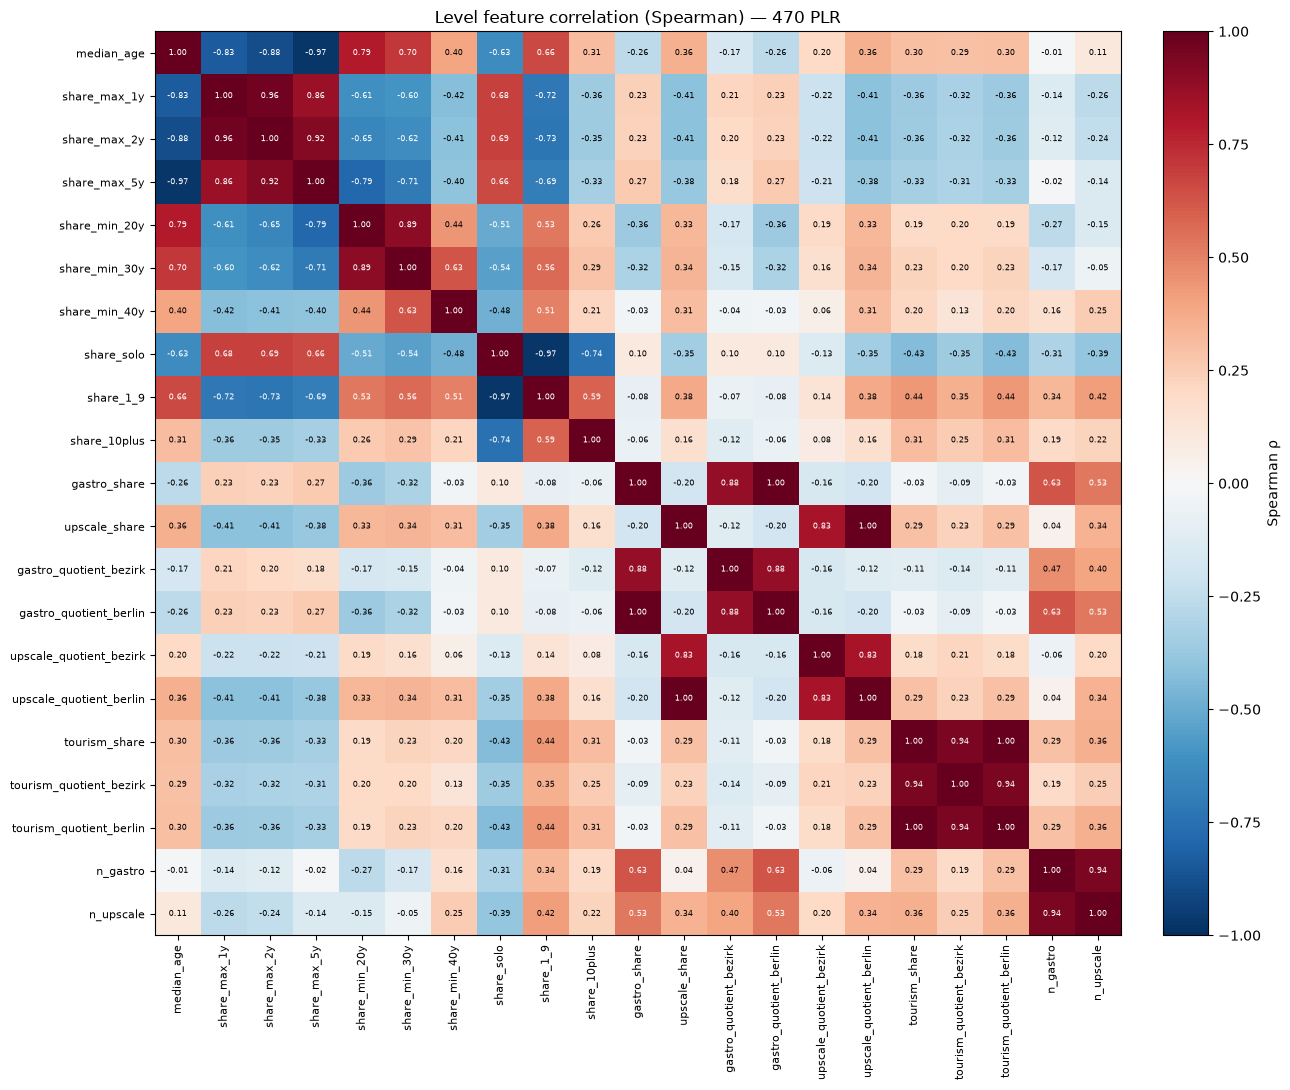

In [62]:
# correlation feature set: levels + raw counts (drop the binary flag; it is not continuous)
corr_cols = level_vars   # already levels + n_gastro/n_upscale

corr = cs[corr_cols].corr(method="spearman")

labels = [c.replace("com_", "").replace("_level_2026", "") for c in corr_cols]
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(corr_cols))); ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(labels, rotation=90, fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        val = corr.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=6, color="white" if abs(val) > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman ρ")
ax.set_title(f"Level feature correlation (Spearman) — {len(cs)} PLR", fontsize=12)
plt.tight_layout()
plt.show()

In [63]:
# strongest pairs (|rho| > 0.6), excluding self-correlations
print("Strong pairs (|ρ| > 0.6):")
pairs = (corr.where(~np.eye(len(corr), dtype=bool))
             .stack().sort_values(key=abs, ascending=False))
seen = set()
for (a, b), v in pairs.items():
    key = frozenset((a, b))
    if key not in seen and abs(v) > 0.6:
        la = a.replace("com_", "").replace("_level_2026", "")
        lb = b.replace("com_", "").replace("_level_2026", "")
        print(f"  {la:34} {lb:34} {v:+.2f}")
        seen.add(key)

Strong pairs (|ρ| > 0.6):
  upscale_share                      upscale_quotient_berlin            +1.00
  gastro_quotient_berlin             gastro_share                       +1.00
  tourism_quotient_berlin            tourism_share                      +1.00
  share_solo                         share_1_9                          -0.97
  median_age                         share_max_5y                       -0.97
  share_max_1y                       share_max_2y                       +0.96
  n_upscale                          n_gastro                           +0.94
  tourism_quotient_bezirk            tourism_share                      +0.94
  tourism_quotient_bezirk            tourism_quotient_berlin            +0.94
  share_max_5y                       share_max_2y                       +0.92
  share_min_30y                      share_min_20y                      +0.89
  median_age                         share_max_2y                       -0.88
  gastro_share                       g

## Step 3 — Slope correlation (Spearman)

Before adopting the level reduction for the slopes, we check whether the trend variables
show the *same* redundancy structure. A high level correlation does not guarantee a high
slope correlation: two variables can share a static state but move independently over time.

Structural redundancies (Berlin quotients, nested age shares, size shares summing to 1)
must also hold for the slopes by construction. The empirical pairs (e.g. median_age vs.
share_max_2y) are the ones to verify here.

Spearman uses pairwise-complete observations, so the few NaN slopes (the upscale trends
with < 12 valid months) are handled automatically.

In [64]:
# the 19 slope variables (same base variables as the levels)
slope_vars = [
    "com_median_age_slope",
    "com_share_max_1y_slope", "com_share_max_2y_slope", "com_share_max_5y_slope",
    "com_share_min_20y_slope", "com_share_min_30y_slope", "com_share_min_40y_slope",
    "com_share_solo_slope", "com_share_1_9_slope", "com_share_10plus_slope",
    "com_gastro_share_slope", "com_upscale_share_slope",
    "com_gastro_quotient_bezirk_slope", "com_gastro_quotient_berlin_slope",
    "com_upscale_quotient_bezirk_slope", "com_upscale_quotient_berlin_slope",
    "com_tourism_share_slope", "com_tourism_quotient_bezirk_slope",
    "com_tourism_quotient_berlin_slope",
]
print(len(slope_vars), "slope variables")
print("slope NaN counts:")
print(cs[slope_vars].isna().sum()[lambda s: s > 0].to_string() or "  none")

19 slope variables
slope NaN counts:
Series([], )


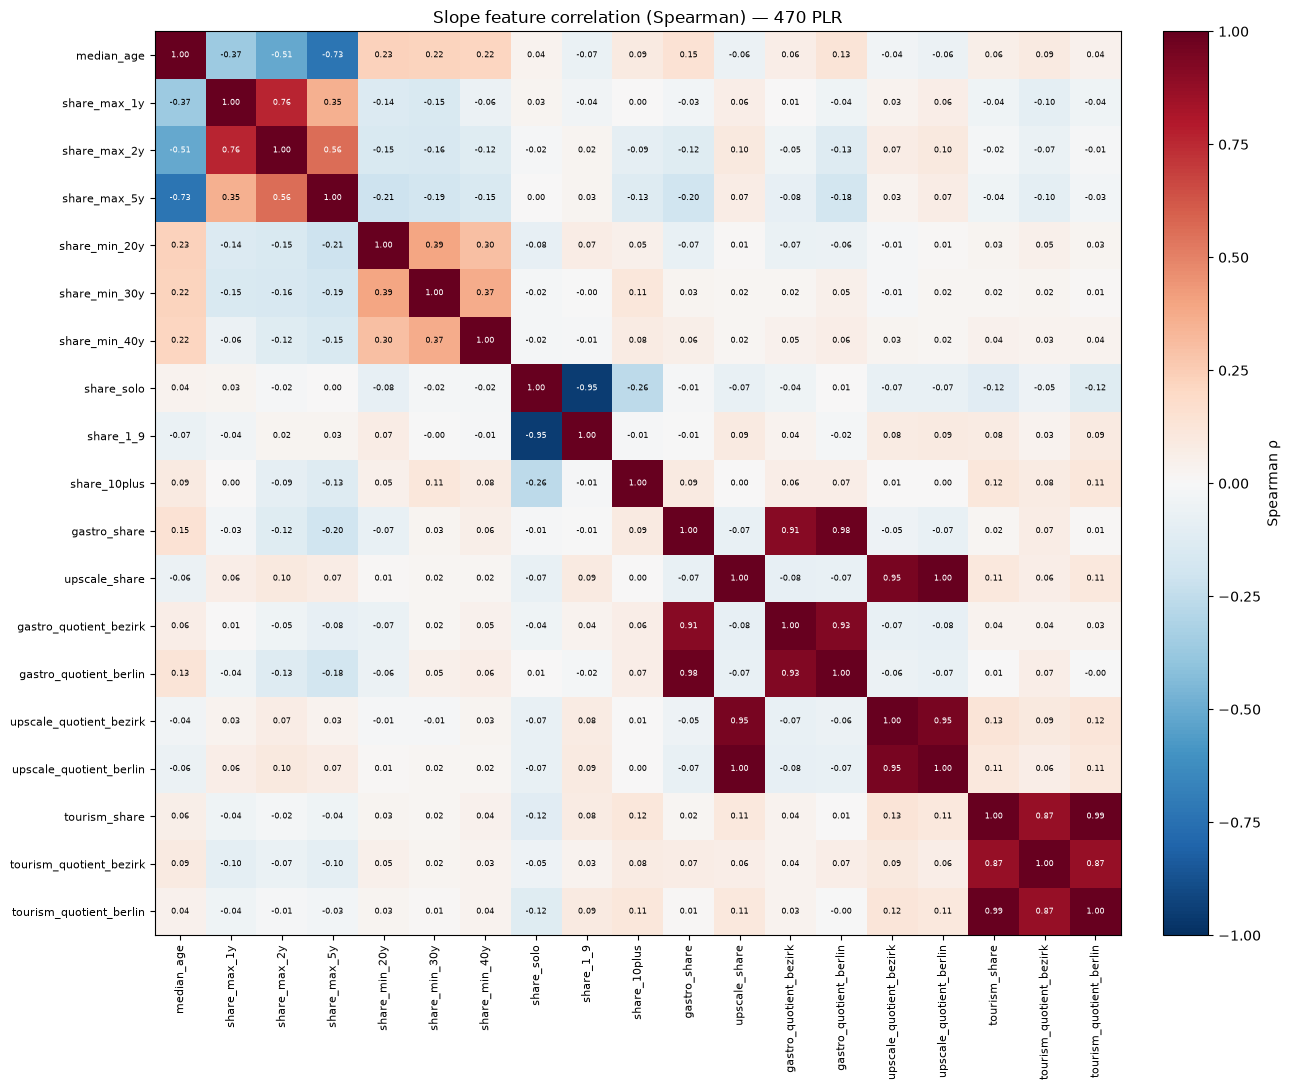

In [65]:
# Spearman heatmap of the slopes (gastro-applicable subset)
corr_s = cs[slope_vars].corr(method="spearman")

labels_s = [c.replace("com_", "").replace("_slope", "") for c in slope_vars]
fig, ax = plt.subplots(figsize=(13, 11))
im = ax.imshow(corr_s, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(slope_vars))); ax.set_yticks(range(len(slope_vars)))
ax.set_xticklabels(labels_s, rotation=90, fontsize=8)
ax.set_yticklabels(labels_s, fontsize=8)
for i in range(len(slope_vars)):
    for j in range(len(slope_vars)):
        val = corr_s.iloc[i, j]
        ax.text(j, i, f"{val:.2f}", ha="center", va="center",
                fontsize=6, color="white" if abs(val) > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman ρ")
ax.set_title(f"Slope feature correlation (Spearman) — {len(cs)} PLR", fontsize=12)
plt.tight_layout()
plt.show()

In [66]:
# strongest slope pairs (|rho| > 0.6)
print("Strong slope pairs (|ρ| > 0.6):")
pairs_s = (corr_s.where(~np.eye(len(corr_s), dtype=bool))
                 .stack().sort_values(key=abs, ascending=False))
seen = set()
for (a, b), v in pairs_s.items():
    key = frozenset((a, b))
    if key not in seen and abs(v) > 0.6:
        la = a.replace("com_", "").replace("_slope", "")
        lb = b.replace("com_", "").replace("_slope", "")
        print(f"  {la:34} {lb:34} {v:+.2f}")
        seen.add(key)

Strong slope pairs (|ρ| > 0.6):
  upscale_share                      upscale_quotient_berlin            +1.00
  tourism_quotient_berlin            tourism_share                      +0.99
  gastro_share                       gastro_quotient_berlin             +0.98
  upscale_quotient_berlin            upscale_quotient_bezirk            +0.95
  upscale_share                      upscale_quotient_bezirk            +0.95
  share_solo                         share_1_9                          -0.95
  gastro_quotient_berlin             gastro_quotient_bezirk             +0.93
  gastro_share                       gastro_quotient_bezirk             +0.91
  tourism_quotient_berlin            tourism_quotient_bezirk            +0.87
  tourism_share                      tourism_quotient_bezirk            +0.87
  share_max_1y                       share_max_2y                       +0.76
  median_age                         share_max_5y                       -0.73


### Comparison: do the slopes share the level redundancy structure?

Compare the strong slope pairs above with the level pairs from Step 2. For each redundancy
group decided on the levels, check whether the corresponding slopes are correlated to a
similar degree:

- **Berlin quotients vs. shares** — expected ρ ≈ 1.00 (structural, holds for slopes too)
- **nested age shares** (max_1y/2y/5y, min_20y/30y/40y) — expected high (structural)
- **size shares** (solo / 1_9 / 10plus) — expected high (sum = 1, structural)
- **median_age vs. share_max_2y** — empirical; verify whether the trends are as strongly
  related as the levels were

If the structure matches, the same 8-variable reduction is adopted for the slopes. Any
pair that is redundant as a level but independent as a slope is flagged for a closer look.

## Correlation findings & variable reduction (slopes)

The Spearman correlation on the slopes was examined separately from the levels. The
structural redundancies carry over, but the age trends behave very differently from the
age levels.

**1. Berlin quotients — perfect redundancy (ρ 0.98–1.00)**
As with the levels, the Berlin-quotient slopes are rescaled copies of the share slopes.
→ **Drop** the three Berlin-quotient slopes.

**2. Bezirk quotients — high redundancy (ρ 0.87–0.95)**
The district-quotient slopes remain highly correlated with the share slopes.
→ **Drop** the three Bezirk-quotient slopes.

**3. Size shares — linear dependency (ρ = −0.95)**
share_solo and share_1_9 slopes are near-mirror images, consistent with the level finding.
→ **Drop** `share_1_9`; keep the two poles `share_solo`, `share_10plus`.

**4. Young-business shares — partial redundancy**
The young-business trends are less tightly linked than as levels: share_max_1y ↔ share_max_2y
is still high (ρ 0.76), but share_max_1y ↔ share_max_5y drops to 0.35. median_age absorbs
share_max_5y (ρ −0.73).
→ **Keep** `share_max_2y`; **drop** `share_max_1y` (redundant with 2y) and `share_max_5y`
(redundant with median_age).

**5. Established-business shares — independent as trends (key difference to the levels)**
This is the main divergence from the level analysis: share_min_20y/30y/40y correlate only
0.30–0.39 as slopes (vs. 0.63–0.89 as levels), and their link to median_age is near zero
(0.22–0.23). The trends therefore carry independent dynamic information.
→ **Keep all three** `share_min_20y`, `share_min_30y`, `share_min_40y`.

**Conclusion:** the slope reduction is less aggressive than the level reduction. Where the
level analysis collapsed the age block into three variables, the slopes retain five
(median_age, share_max_2y, and all three established-business trends), because their
dynamics are genuinely independent. This yields 10 slope variables vs. 8 level variables —
an intentional, data-driven asymmetry.

## Final variable selection (after redundancy analysis)

Redundancy was assessed in three steps: separate level and slope correlations, then an
**overall correlation** of the reduced sets together. The overall check revealed that the
remaining level demographics still lie on one shared age/size axis (median_age, share_max_2y,
share_min_30y mutually correlated 0.62–0.88), and that the two counts are near-duplicates
(n_gastro ↔ n_upscale, ρ 0.94). The level set is therefore reduced further, while the slopes
are kept (their trends are independent — see Step 3).

### Dropped for both representations
- **Berlin quotients** (ρ ≈ 1.00) and **Bezirk quotients** (ρ 0.83–0.95)
- **share_1_9** (size shares sum to 1)

### Age variables — representation-specific (key asymmetry)
- **Levels:** the age axis is collapsed to **median_age only** — share_max_2y (ρ −0.88) and
  share_min_30y (ρ +0.70) are dropped as levels because they restate the same axis.
- **Slopes:** keep median_age, share_max_2y and all three share_min_20y/30y/40y — their
  *trends* are largely independent (ρ 0.30–0.39, see Step 3).

### Counts
- **Drop n_upscale** (ρ 0.94 with n_gastro); keep **n_gastro** (broader, and the basis for
  has_gastro_structure).

### Resulting model matrix

**Levels (6):** median_age, share_solo, share_10plus, gastro_share, upscale_share, tourism_share

**Slopes (10):** median_age, share_max_2y, share_min_20y, share_min_30y, share_min_40y,
share_solo, share_10plus, gastro_share, upscale_share, tourism_share

**R² (10):** trend quality for each kept slope

**Structure (2):** n_gastro, has_gastro_structure

Total: 6 + 10 + 10 + 2 = **28 feature columns** (+ plr_id), down from 60.

> The asymmetry (6 levels vs. 10 slopes) is intentional and data-driven: the demographic
> *state* is largely one-dimensional (age/size collapse onto one axis), whereas the
> demographic *dynamics* are independent and worth keeping in full.

In [67]:
# final variable sets after redundancy analysis (separate + overall correlation)
level_final = [
    "com_median_age_level_2026",
    "com_share_solo_level_2026", "com_share_10plus_level_2026",
    "com_gastro_share_level_2026", "com_upscale_share_level_2026", "com_tourism_share_level_2026",
]
slope_final = [
    "com_median_age_slope", "com_share_max_2y_slope",
    "com_share_min_20y_slope", "com_share_min_30y_slope", "com_share_min_40y_slope",
    "com_share_solo_slope", "com_share_10plus_slope",
    "com_gastro_share_slope", "com_upscale_share_slope", "com_tourism_share_slope",
]
print(len(level_final), "level vars |", len(slope_final), "slope vars")

6 level vars | 10 slope vars


## Step 4 — Overall correlation matrix (final check)

Combined Spearman correlation of the reduced sets — **8 levels + 10 slopes + 2 counts**
(R² excluded). This is the final redundancy check before the detailed analyses: it surfaces
any cross-type correlation that the separate level/slope matrices could not show — e.g. a
level correlated with another variable's slope, or a count correlated with a share. Anything
strongly redundant here is a candidate to drop before modelling.

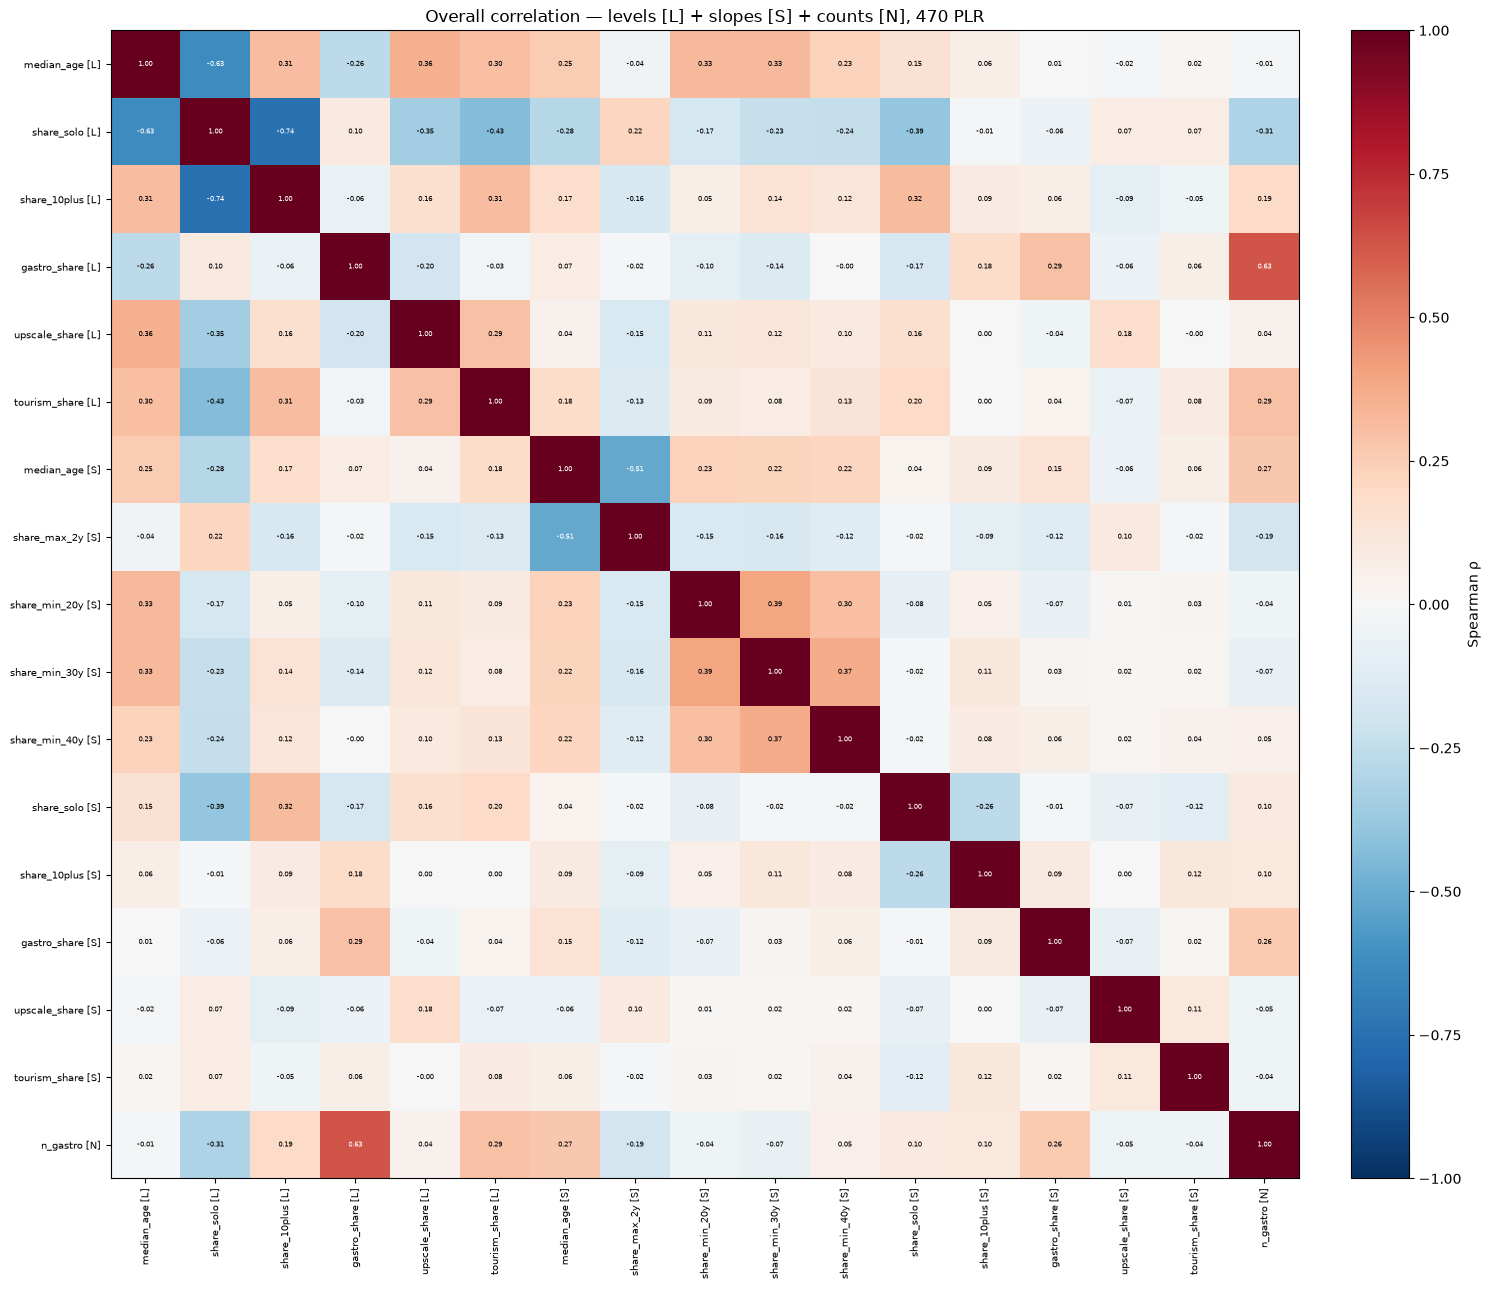

In [68]:
# overall feature set: reduced levels + reduced slopes + the two counts (no R2)
overall_cols = level_final + slope_final + ["com_n_gastro"]
corr_o = cs[overall_cols].corr(method="spearman")

def lab_o(c):
    if c == "com_n_gastro":  return "n_gastro [N]"
    b = c.replace("com_","").replace("_level_2026","").replace("_slope","")
    tag = "L" if c.endswith("_level_2026") else "S"
    return f"{b} [{tag}]"
labels_o = [lab_o(c) for c in overall_cols]

fig, ax = plt.subplots(figsize=(15, 13))
im = ax.imshow(corr_o, cmap="RdBu_r", vmin=-1, vmax=1, aspect="auto")
ax.set_xticks(range(len(overall_cols))); ax.set_yticks(range(len(overall_cols)))
ax.set_xticklabels(labels_o, rotation=90, fontsize=7)
ax.set_yticklabels(labels_o, fontsize=7)
for i in range(len(overall_cols)):
    for j in range(len(overall_cols)):
        v = corr_o.iloc[i, j]
        ax.text(j, i, f"{v:.2f}", ha="center", va="center",
                fontsize=5, color="white" if abs(v) > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label="Spearman ρ")
ax.set_title(f"Overall correlation — levels [L] + slopes [S] + counts [N], {len(cs)} PLR", fontsize=12)
plt.tight_layout()
plt.show()

In [69]:
# strong pairs in the overall set (|rho| > 0.6), excluding self
print("Strong pairs in overall set (|ρ| > 0.6):")
pairs_o = (corr_o.where(~np.eye(len(corr_o), dtype=bool))
                 .stack().sort_values(key=abs, ascending=False))
seen = set()
any_found = False
for (a, b), v in pairs_o.items():
    key = frozenset((a, b))
    if key not in seen and abs(v) > 0.6:
        print(f"  {lab_o(a):26} {lab_o(b):26} {v:+.2f}")
        seen.add(key); any_found = True
if not any_found:
    print("  none — the reduced feature set is well de-correlated")

Strong pairs in overall set (|ρ| > 0.6):
  share_10plus [L]           share_solo [L]             -0.74
  n_gastro [N]               gastro_share [L]           +0.63
  median_age [L]             share_solo [L]             -0.63


## Step 5 — A closer look at the slopes

Three views that are meaningful for trends (unlike histograms):
1. **Direction overview** — how many PLR rise vs. fall per variable, and the median slope
   (is the city moving up on average?)
2. **Level vs. slope scatter** — do already-high Kieze keep rising (reinforcement / divergence)
   or do low ones catch up (convergence)?
3. **Top movers** — the PLR with the strongest positive / negative trends per variable.

These use the final slope set (10 variables) decided in the redundancy analysis.

### 5.1 — Direction overview

For each slope: how many PLR have a rising (>0), falling (<0) or flat (=0) trend, the
share rising, and the median slope. A median clearly above zero means the city as a whole
is trending upward on that variable.

In [70]:
rows = []
for col in slope_final:
    s = cs[col].dropna()
    n = len(s)
    n_up = int((s > 0).sum()); n_down = int((s < 0).sum()); n_flat = int((s == 0).sum())
    rows.append({
        "variable": col.replace("com_", "").replace("_slope", ""),
        "n": n,
        "rising": n_up, "falling": n_down, "flat": n_flat,
        "% rising": round(n_up / n * 100, 1) if n else float("nan"),
        "median_slope": round(s.median(), 5),
        "mean_slope": round(s.mean(), 5),
    })
direction = pd.DataFrame(rows).sort_values("% rising", ascending=False)
print(direction.to_string(index=False))

     variable   n  rising  falling  flat  % rising  median_slope  mean_slope
share_min_20y 470     423       47     0      90.0       0.00639     0.00620
   share_solo 470     408       62     0      86.8       0.00813     0.00892
share_min_30y 470     348      122     0      74.0       0.00138     0.00168
 gastro_share 470     318      152     0      67.7       0.00082     0.00074
 share_max_2y 470     240      230     0      51.1       0.00031     0.00061
 share_10plus 470     237      232     1      50.4       0.00002     0.00003
upscale_share 470     226      240     4      48.1      -0.00066     0.00060
   median_age 470     217      207    46      46.2       0.00000    -0.01144
share_min_40y 470     205      203    62      43.6       0.00000     0.00009
tourism_share 470     159      214    97      33.8       0.00000     0.00002


### 5.2 — Level vs. slope (reinforcement or convergence?)

Each point is a PLR: x = current level (2026), y = trend (slope). A **positive** relationship
means high-level Kieze are still rising (reinforcement / divergence); a **negative** one means
low-level Kieze are catching up (convergence). The Spearman ρ between level and slope is shown
per panel. Only variables that have both a level and a slope in the final sets are plotted.

variables with both level & slope: ['median_age', 'share_solo', 'share_10plus', 'gastro_share', 'upscale_share', 'tourism_share']


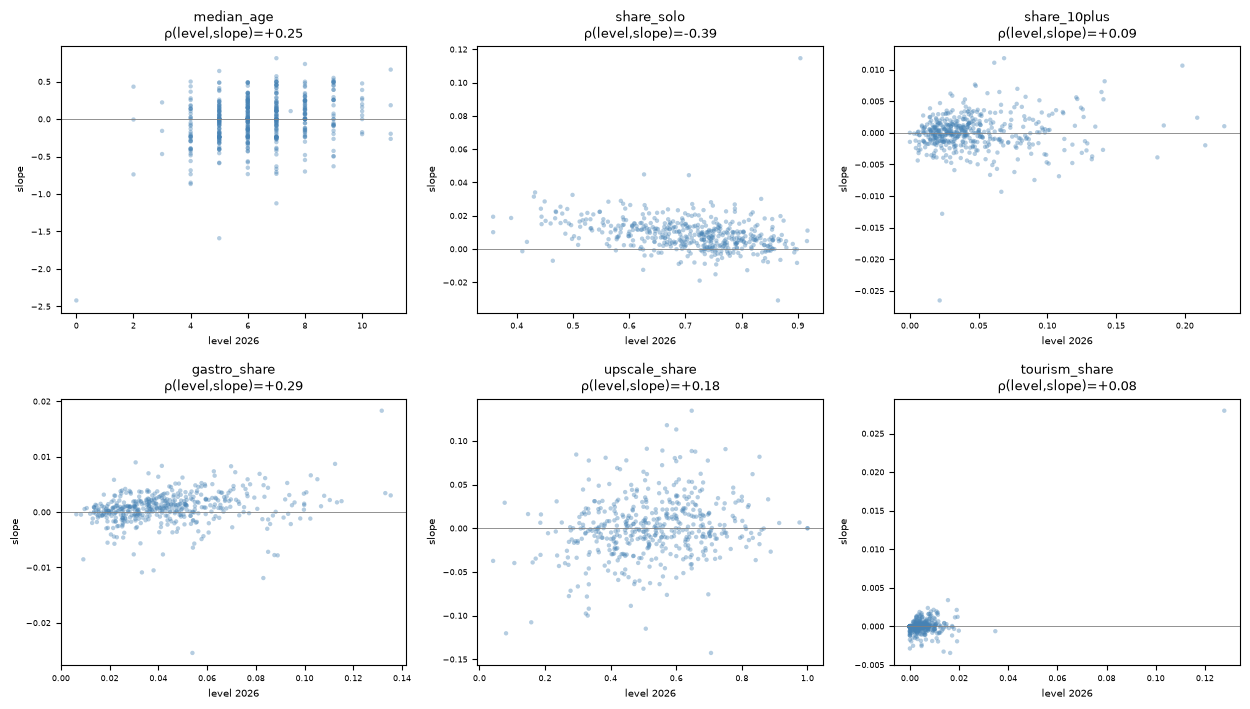

In [71]:
from scipy.stats import spearmanr

# variables present in BOTH final sets (match base names)
def base(c): return c.replace("com_","").replace("_level_2026","").replace("_slope","")
lvl_base = {base(c): c for c in level_final}
slp_base = {base(c): c for c in slope_final}
common = [b for b in lvl_base if b in slp_base]
print("variables with both level & slope:", common)

n = len(common)
ncol = 3
nrow = int(np.ceil(n / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2*ncol, 3.6*nrow))
axes = np.array(axes).reshape(-1)
for k, b in enumerate(common):
    ax = axes[k]
    x = cs[lvl_base[b]]; y = cs[slp_base[b]]
    m = x.notna() & y.notna()
    ax.scatter(x[m], y[m], s=10, alpha=0.4, color="steelblue", edgecolor="none")
    ax.axhline(0, color="grey", lw=0.6)
    if m.sum() > 2:
        rho, _ = spearmanr(x[m], y[m])
        ax.set_title(f"{b}\nρ(level,slope)={rho:+.2f}", fontsize=9)
    ax.set_xlabel("level 2026", fontsize=7); ax.set_ylabel("slope", fontsize=7)
    ax.tick_params(labelsize=6)
for k in range(n, len(axes)):
    axes[k].axis("off")
plt.tight_layout()
plt.show()

### 5.3 — Top movers

The PLR with the strongest upward and downward trend per variable. These are the hotspots
of change — useful for sanity-checking and for naming concrete Kieze in the analysis.

In [72]:
TOP = 5
for col in slope_final:
    name = col.replace("com_", "").replace("_slope", "")
    s = cs[[ "plr_id", col]].dropna(subset=[col]).sort_values(col)
    top_up = s.tail(TOP).iloc[::-1]
    top_down = s.head(TOP)
    print(f"\n=== {name} ===")
    print("  strongest RISING:")
    for _, r in top_up.iterrows():
        print(f"    {r['plr_id']}  {r[col]:+.5f}")
    print("  strongest FALLING:")
    for _, r in top_down.iterrows():
        print(f"    {r['plr_id']}  {r[col]:+.5f}")


=== median_age ===
  strongest RISING:
    02400625  +0.81236
    02100102  +0.73514
    04400834  +0.66023
    07400822  +0.64170
    06300630  +0.57143
  strongest FALLING:
    07501029  -2.42008
    09401433  -1.58996
    08200730  -1.12432
    05200633  -0.86641
    10200420  -0.84865

=== share_max_2y ===
  strongest RISING:
    07501029  +0.21655
    07200410  +0.05930
    10200525  +0.04149
    05200423  +0.03971
    05100317  +0.03873
  strongest FALLING:
    04200203  -0.07909
    07400822  -0.06731
    01100205  -0.06150
    05100210  -0.05756
    02200207  -0.04575

=== share_min_20y ===
  strongest RISING:
    07501135  +0.02991
    11200512  +0.02302
    08200726  +0.02282
    03200309  +0.02245
    10100210  +0.02126
  strongest FALLING:
    08200728  -0.03505
    07501029  -0.02970
    08401138  -0.01053
    07200410  -0.01028
    08200730  -0.01016

=== share_min_30y ===
  strongest RISING:
    09501736  +0.01884
    10300734  +0.01286
    11200512  +0.01167
    104008

## Step 6 — Slope quality (R²)

How reliable is each trend? R² measures how well the linear fit describes the 36-month
series: high = clean linear trend, low = noisy / non-linear. R² is **NaN when the series is
flat** (no variance — undefined), which is different from a missing value. The overview
below therefore reports, per variable, the mean/median R² over the *defined* values, the
number of flat-series NaN, and the share of "reliable" trends (R² > 0.3).

Reading guide: a high mean R² (e.g. gastro_share) means the trend is trustworthy; a low one
(e.g. upscale_share — small denominators) means the slope captures direction but is noisy.

In [73]:
# R2 columns for the final 10 slope variables
r2_final = [c.replace("_slope", "_r2") for c in slope_final]

R2_RELIABLE = 0.30   # threshold for "reliable" linear trend
rows = []
for col in r2_final:
    s = cs[col]
    defined = s.dropna()
    n_def = len(defined)
    n_nan = int(s.isna().sum())   # flat series (or <12 months)
    rows.append({
        "variable": col.replace("com_", "").replace("_r2", ""),
        "n_defined": n_def,
        "R2_mean": round(defined.mean(), 3) if n_def else float("nan"),
        "R2_median": round(defined.median(), 3) if n_def else float("nan"),
        "flat_NaN": n_nan,
        "%_reliable(R2>0.3)": round((defined > R2_RELIABLE).mean() * 100, 1) if n_def else float("nan"),
    })
r2_tab = pd.DataFrame(rows).sort_values("R2_mean", ascending=False)
print(r2_tab.to_string(index=False))

     variable  n_defined  R2_mean  R2_median  flat_NaN  %_reliable(R2>0.3)
share_min_20y        470    0.653      0.767         0                83.6
share_min_30y        470    0.504      0.572         0                68.9
   share_solo        470    0.474      0.529         0                67.9
share_min_40y        408    0.419      0.407        62                60.5
 share_10plus        469    0.381      0.365         1                55.0
 gastro_share        470    0.376      0.347         0                54.0
tourism_share        373    0.374      0.340        97                53.9
 share_max_2y        470    0.370      0.319         0                52.3
upscale_share        468    0.338      0.309         2                51.3
   median_age        425    0.266      0.202        45                36.7


### 6.1 — Mean R² per variable (bar chart)

Quick visual ranking of trend reliability. Taller bar = straighter, more trustworthy trend.

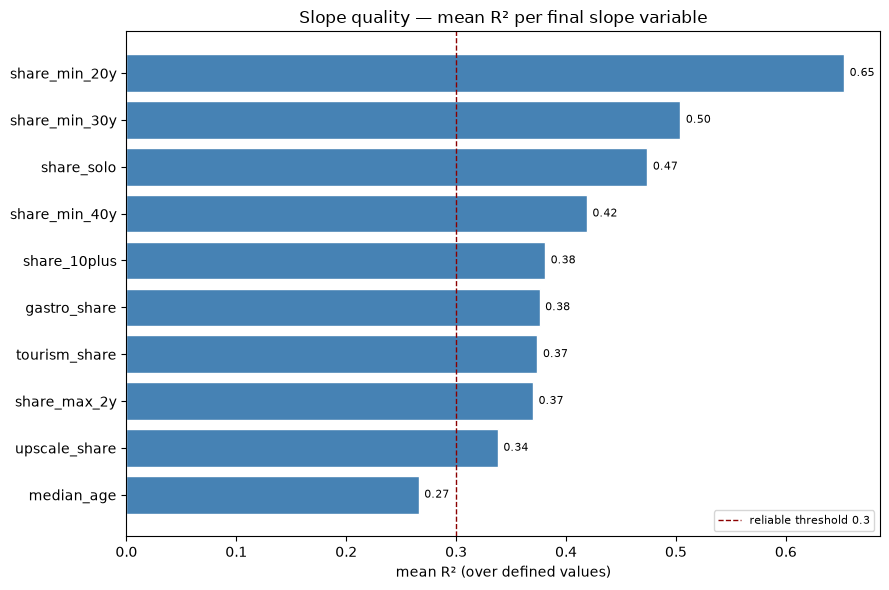

In [74]:
order = r2_tab.sort_values("R2_mean", ascending=True)
fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(order["variable"], order["R2_mean"], color="steelblue", edgecolor="white")
ax.axvline(R2_RELIABLE, color="darkred", linestyle="--", linewidth=1, label=f"reliable threshold {R2_RELIABLE}")
ax.set_xlabel("mean R² (over defined values)")
ax.set_title("Slope quality — mean R² per final slope variable", fontsize=12)
ax.legend(fontsize=8)
for b, v in zip(bars, order["R2_mean"]):
    ax.text(v + 0.005, b.get_y() + b.get_height()/2, f"{v:.2f}", va="center", fontsize=8)
plt.tight_layout()
plt.show()

### 6.2 — R² distribution per variable (boxplots)

The spread shows how consistent the trend quality is across PLR. A box sitting high and tight
means most PLR have a clean trend; a low, wide box means quality varies a lot.

/var/folders/7q/_3kvzzyn72dcy5l9z5985fsm0000gn/T/ipykernel_5605/3089712846.py:8: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  bp = ax.boxplot(data_box, vert=True, tick_labels=order_box, patch_artist=True,


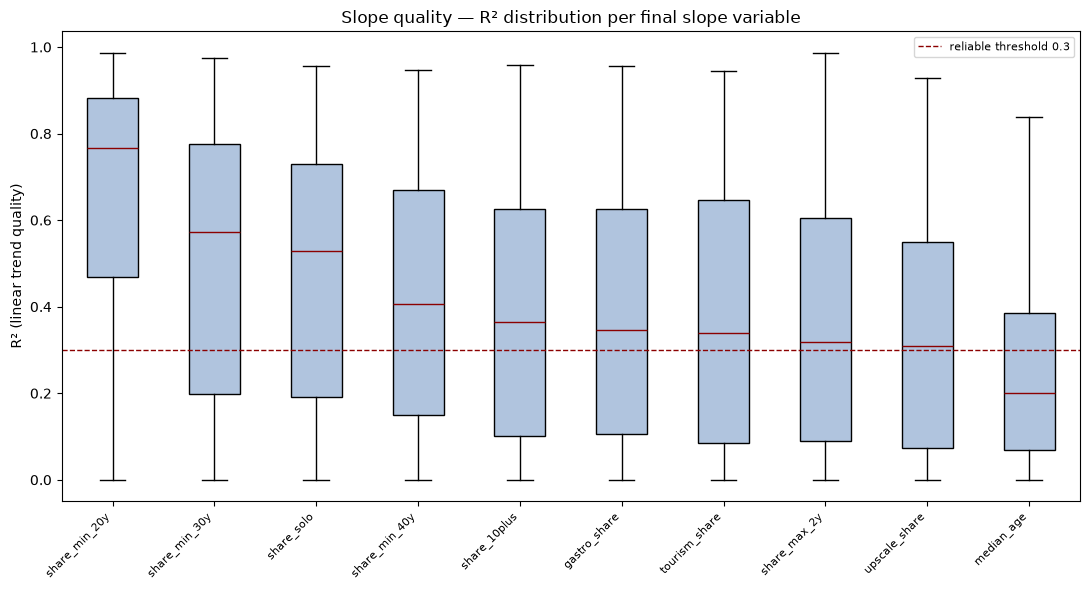

In [76]:
# boxplots of R2 per variable (defined values only), ordered by median
order_box = r2_tab.sort_values("R2_median", ascending=False)["variable"].tolist()
data_box = [cs[f"com_{v}_r2"].dropna().values for v in order_box]

fig, ax = plt.subplots(figsize=(11, 6))
# matplotlib >= 3.9 renamed labels -> tick_labels; support both
try:
    bp = ax.boxplot(data_box, vert=True, tick_labels=order_box, patch_artist=True,
                    medianprops=dict(color="darkred"))
except TypeError:
    bp = ax.boxplot(data_box, vert=True, labels=order_box, patch_artist=True,
                    medianprops=dict(color="darkred"))
for patch in bp["boxes"]:
    patch.set_facecolor("lightsteelblue")
ax.axhline(R2_RELIABLE, color="darkred", linestyle="--", linewidth=1, label=f"reliable threshold {R2_RELIABLE}")
ax.set_ylabel("R² (linear trend quality)")
ax.set_title("Slope quality — R² distribution per final slope variable", fontsize=12)
ax.set_xticklabels(order_box, rotation=45, ha="right", fontsize=8)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### R² findings — trend reliability

The R² of the slope fits varies systematically across variables, and the pattern is
substantively coherent: structurally slow-moving variables produce the straightest trends,
while fast-moving or small-base variables produce noisier ones.

**Most reliable trends**
- `share_min_20y` is by far the cleanest (R²_mean 0.65, median 0.77, 83.6 % of PLR above
  the 0.3 threshold). The share of long-established businesses (≥ 20 years) changes slowly
  but steadily.
- `share_min_30y` (0.50), `share_solo` (0.47) and `share_min_40y` (0.42) follow.

**Noisiest trends**
- `median_age` is the weakest (R²_mean 0.27, median 0.20, only 36.7 % reliable). This is
  expected: business age is an integer year value that updates only annually, so the
  monthly trend is inherently stepwise and hard to fit linearly.
- `upscale_share` (0.34), `share_max_2y` (0.37), `tourism_share` (0.37) and `gastro_share`
  (0.38) sit near the threshold — the upscale noise reflects the small-denominator issue.

**Structural flatness (flat_NaN)**
Several variables are flat (no variance → R² undefined) in many PLR — an *inhaltlicher*
finding, not a measurement gap:
- `tourism_share`: flat in **97** PLR — almost one in five Kieze has no tourism trend at
  all, confirming that accommodation is spatially highly concentrated and static elsewhere.
- `share_min_40y`: flat in 62 PLR; `median_age`: flat in 45 PLR.

**Consequence for interpretation:** trend direction is robust throughout, but the exact
slope magnitude of the low-R² variables (median_age, upscale_share) should be read with
caution. The established-business trends, by contrast, support confident interpretation.
R² is used for this interpretive purpose only — it is not a model feature and was not used
to drop any slope.

## Step 7 — Export the reduced model matrix

Final output step (the only cell that writes files). Two datasets are written to
`data/final_datasets/`:

- **feature_matrix_commercial_reduced.csv** — the model-ready table: 6 levels + 10 slopes
  + n_gastro + has_gastro_structure = 18 feature columns (+ plr_id). R² is *not* included
  (used for interpretation only, not as a model feature).
- **feature_matrix_commercial_r2.csv** — the R² of the 10 kept slopes (+ plr_id), kept
  separately to document trend reliability for interpretation.

The full 60-column `feature_matrix_commercial.csv` remains untouched as the raw product.
All columns keep the `com_` prefix and the `plr_id` key for cross-dimension merging.

In [77]:
# --- build the reduced model matrix (18 feature cols + plr_id) ---
model_cols = (
    ["plr_id"]
    + level_final            # 6 levels
    + slope_final            # 10 slopes
    + ["com_n_gastro", "com_has_gastro_structure"]   # 2 context
)
missing = [c for c in model_cols if c not in df.columns]
assert not missing, f"missing columns: {missing}"

reduced = df[model_cols].copy()
print("reduced matrix:", reduced.shape, "(expect 542 x 19)")
print("all feature cols com_-prefixed:",
      all(c.startswith("com_") for c in reduced.columns if c != "plr_id"))

# --- R2 of the kept slopes, separate file for interpretation ---
r2_cols = ["plr_id"] + [c.replace("_slope", "_r2") for c in slope_final]
missing_r2 = [c for c in r2_cols if c not in df.columns]
assert not missing_r2, f"missing R2 columns: {missing_r2}"
r2_df = df[r2_cols].copy()
print("R2 matrix:", r2_df.shape, "(expect 542 x 11)")

# --- write both ---
out_dir = Path("../../data/final_datasets")
reduced_path = out_dir / "feature_matrix_commercial_reduced.csv"
r2_path = out_dir / "feature_matrix_commercial_r2.csv"
reduced.to_csv(reduced_path, index=False)
r2_df.to_csv(r2_path, index=False)
print("written:", reduced_path)
print("written:", r2_path)

reduced matrix: (542, 19) (expect 542 x 19)
all feature cols com_-prefixed: True
R2 matrix: (542, 11) (expect 542 x 11)
written: ../../data/final_datasets/feature_matrix_commercial_reduced.csv
written: ../../data/final_datasets/feature_matrix_commercial_r2.csv


In [78]:
# quick sanity summary of the reduced matrix
print("=== reduced model matrix columns ===")
for c in reduced.columns:
    na = int(reduced[c].isna().sum())
    print(f"  {c:38} NaN={na}")
print("\nNote: NaN handling (e.g. upscale levels/slopes) is a modelling-step decision,")
print("deferred to preprocessing (drop / impute) per model. K-Means needs no NaN; XGBoost handles them natively.")

=== reduced model matrix columns ===
  plr_id                                 NaN=0
  com_median_age_level_2026              NaN=0
  com_share_solo_level_2026              NaN=0
  com_share_10plus_level_2026            NaN=0
  com_gastro_share_level_2026            NaN=0
  com_upscale_share_level_2026           NaN=5
  com_tourism_share_level_2026           NaN=0
  com_median_age_slope                   NaN=0
  com_share_max_2y_slope                 NaN=0
  com_share_min_20y_slope                NaN=0
  com_share_min_30y_slope                NaN=0
  com_share_min_40y_slope                NaN=0
  com_share_solo_slope                   NaN=0
  com_share_10plus_slope                 NaN=0
  com_gastro_share_slope                 NaN=0
  com_upscale_share_slope                NaN=4
  com_tourism_share_slope                NaN=0
  com_n_gastro                           NaN=0
  com_has_gastro_structure               NaN=0

Note: NaN handling (e.g. upscale levels/slopes) is a modelling-step d